<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Computer-Vision/blob/main/Practicals/CR_Pract_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/Computer Vision"

/content/drive/MyDrive/Colab Notebooks/Computer Vision


In [ ]:
# Load grayscale image
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)
img_f = img.astype(np.float32)



In [ ]:

# Step 1: Blur the image (this is f̄)
blurred = cv2.GaussianBlur(img_f, (5, 5), 0)


In [ ]:

# Step 2: Create the mask (edge/detail information)
mask = img_f - blurred


In [ ]:
# Step 3: Standard unsharp masking (k = 1)
k = 1.0
unsharp = img_f + k * mask
unsharp = np.clip(unsharp, 0, 255).astype(np.uint8)


In [ ]:

# Step 4: High-boost filtering (A > 1, here A = 1.5 -> k = A-1 = 0.5, done via addWeighted)
A = 1.5
high_boost = cv2.addWeighted(img_f, A, blurred, -(A - 1), 0)
high_boost = np.clip(high_boost, 0, 255).astype(np.uint8)

img_disp = np.uint8(img_f)
mask_disp = cv2.normalize(mask, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)



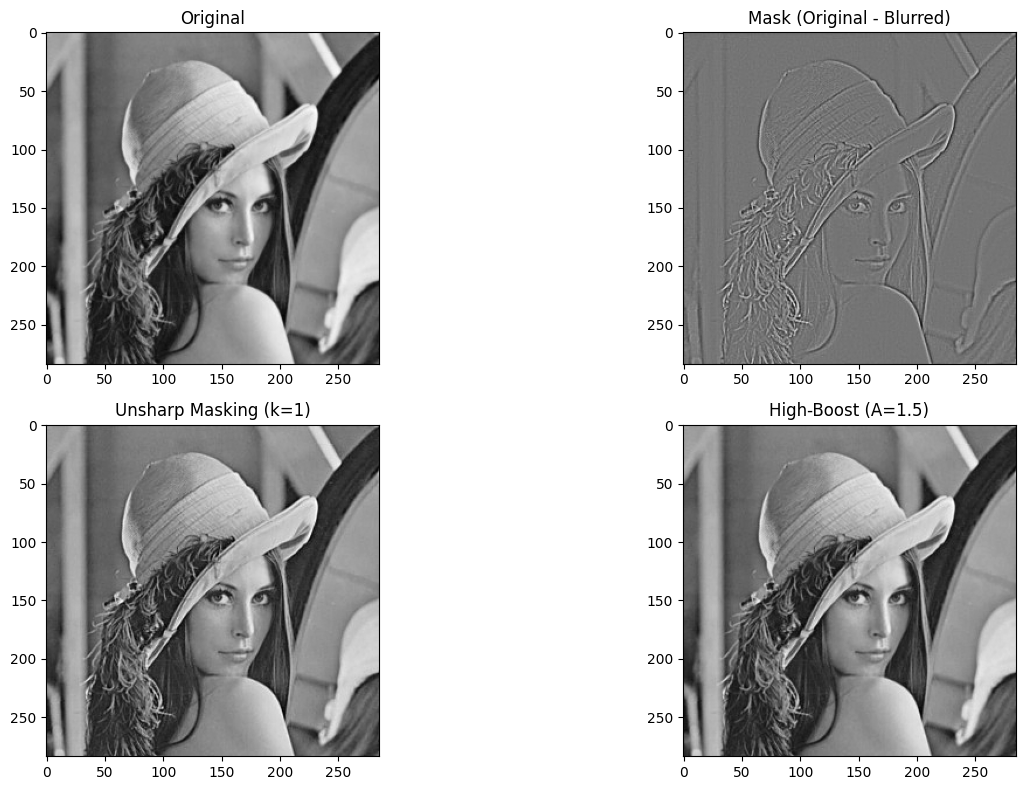

In [ ]:
# Display results
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1), plt.imshow(img_disp, cmap='gray'), plt.title('Original')
plt.subplot(2, 2, 2), plt.imshow(mask_disp, cmap='gray'), plt.title('Mask (Original - Blurred)')
plt.subplot(2, 2, 3), plt.imshow(unsharp, cmap='gray'), plt.title('Unsharp Masking (k=1)')
plt.subplot(2, 2, 4), plt.imshow(high_boost, cmap='gray'), plt.title('High-Boost (A=1.5)')

plt.tight_layout()
plt.show()

